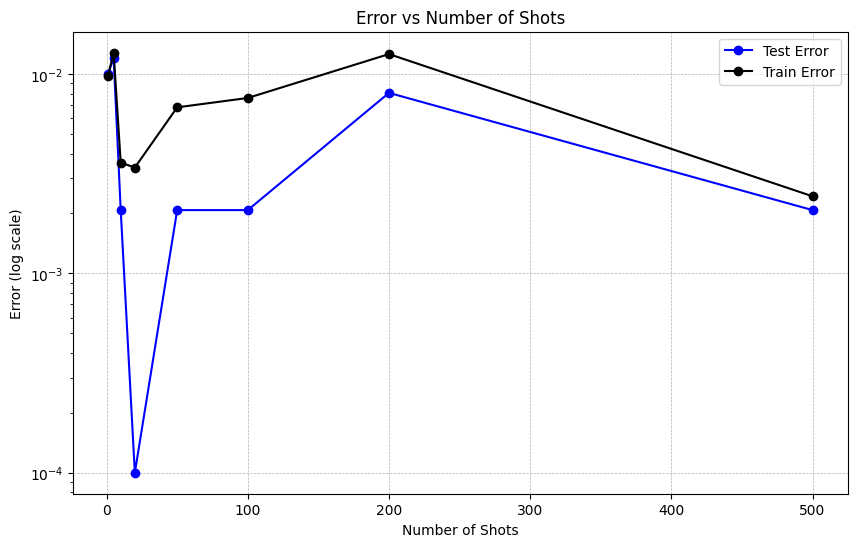

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

model = "clip"
# Load results CSV
data = pd.read_csv(f"/home/yashsalunkhe619/directional_cdnv_bounds/results/{model}/mini_imagenet/results.csv")

# Robustly parse accuracy columns (they may be strings like "[0.812]")
if 'test_acc' in data.columns:
    data['test_acc'] = data['test_acc'].astype(str).str.replace(r'[\[\]\s]', '', regex=True).astype(float)
if 'train_acc' in data.columns:
    data['train_acc'] = data['train_acc'].astype(str).str.replace(r'[\[\]\s]', '', regex=True).astype(float)

# Compute errors and apply a small floor to avoid zeros on a log plot
FLOOR = 1e-4
if 'test_acc' in data.columns:
    data['test_error'] = 1.0 - data['test_acc']
    data.loc[data['test_error'] <= 0.0, 'test_error'] = FLOOR
if 'train_acc' in data.columns:
    data['train_error'] = 1.0 - data['train_acc']
    data.loc[data['train_error'] <= 0.0, 'train_error'] = FLOOR

# Ensure n_shot is numeric for grouping
data['n_shot'] = pd.to_numeric(data['n_shot'], errors='coerce').astype(int)

# Group by n_shot and average
grouped_test = data.groupby('n_shot', sort=True)['test_error'].mean().sort_index() if 'test_error' in data.columns else None
grouped_train = data.groupby('n_shot', sort=True)['train_error'].mean().sort_index() if 'train_error' in data.columns else None

# Plot errors
plt.figure(figsize=(10, 6))
plt.yscale('log')
if grouped_test is not None:
    plt.plot(grouped_test.index, grouped_test.values, marker='o', linestyle='-', color='b', label='Test Error')
if grouped_train is not None:
    plt.plot(grouped_train.index, grouped_train.values, marker='o', linestyle='-', color='k', label='Train Error')
plt.title('Error vs Number of Shots')
plt.xlabel('Number of Shots')
plt.ylabel('Error (log scale)')
plt.grid(True, linestyle='--', linewidth=0.5)
plt.legend()
plt.show()


In [27]:
from bound_analysis.bound_core import compute_error_bound_for_m


import sys, os, argparse, yaml, pandas as pd


import torch
torch.set_default_dtype(torch.float32)
import random
from encoders.get_encoders import build_ssl_encoder
from data_utils.dataloaders import get_dataset
from eval_utils.feature_extractor import FeatureExtractor
from eval_utils.nccc_utils import NCCCEvaluator
def freeze_model(model):
    for param in model.parameters():
        param.requires_grad = False

def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False  # Ensures determinism




In [28]:
config_file = f"/home/yashsalunkhe619/directional_cdnv_bounds/configs/{model}_config.yaml"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
set_seed(42)


with open(config_file, 'r') as f:

    config = yaml.safe_load(f)
    num_output_classes = config['dataset']['num_output_classes']
    classes_group = random.sample(range(num_output_classes), 2)
    _, train_loader, _, test_loader, train_labels, test_labels = get_dataset(
        dataset_name=config['dataset']['name'],
        dataset_path=config['dataset']['path'],
        augment_both_views=config['linear']['augment_both'],
        batch_size=config['linear']['batch_size'],
        test=True,
    )

    ssl_model = build_ssl_encoder(
    method=config['method_type'],
    encoder_type=config['model']['encoder_type'],
    dataset=config['dataset']['name'],
    checkpoint=None,
    device=device,
)
    

In [ ]:
from eval_utils.geometry import GeometricEvaluator

num_classes = config['dataset']['num_output_classes']
geometric_evaluator = GeometricEvaluator(num_classes=num_classes, device=device)

feature_extractor = FeatureExtractor(ssl_model, device=device)
train_features, train_labels = feature_extractor.extract_features(train_loader)
test_features, test_labels = feature_extractor.extract_features(test_loader)

cdnv = geometric_evaluator.compute_cdnv(train_features[0], train_labels)
directional_cdnv = geometric_evaluator.compute_directional_cdnv(train_features[0], train_labels)

print(f"CDNV: {cdnv}")
print(f"Directional CDNV: {directional_cdnv}")

Extracting Features:   5%|▍         | 18/391 [00:04<01:23,  4.48it/s]

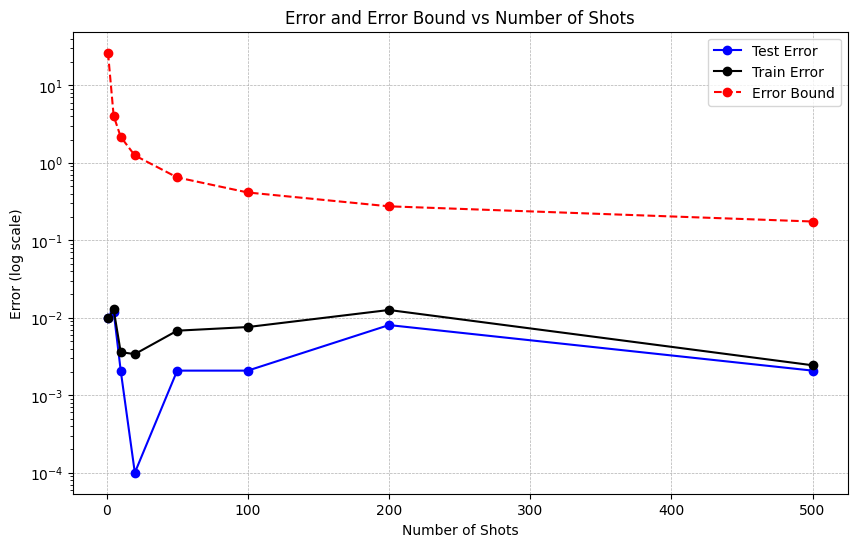

In [39]:
from bound_analysis.bound_core import compute_error_bound_for_m

m_shots = grouped_test.index  
error_bounds = [compute_error_bound_for_m(directional_cdnv, cdnv, m) for m in m_shots]

plt.figure(figsize=(10, 6))
plt.yscale('log')
#plt.xscale('log')
plt.plot(m_shots, grouped_test.values, marker='o', linestyle='-', color='b', label='Test Error')
plt.plot(m_shots, grouped_train.values, marker='o', linestyle='-', color='k', label='Train Error')
plt.plot(m_shots, error_bounds, marker='o', linestyle='--', color='r', label='Error Bound')
plt.title('Error and Error Bound vs Number of Shots')
plt.xlabel('Number of Shots')
plt.ylabel('Error (log scale)')
plt.grid(True, linestyle='--', linewidth=0.5)
plt.legend()
plt.show()

Extracting Features: 100%|██████████| 391/391 [01:04<00:00,  6.08it/s]


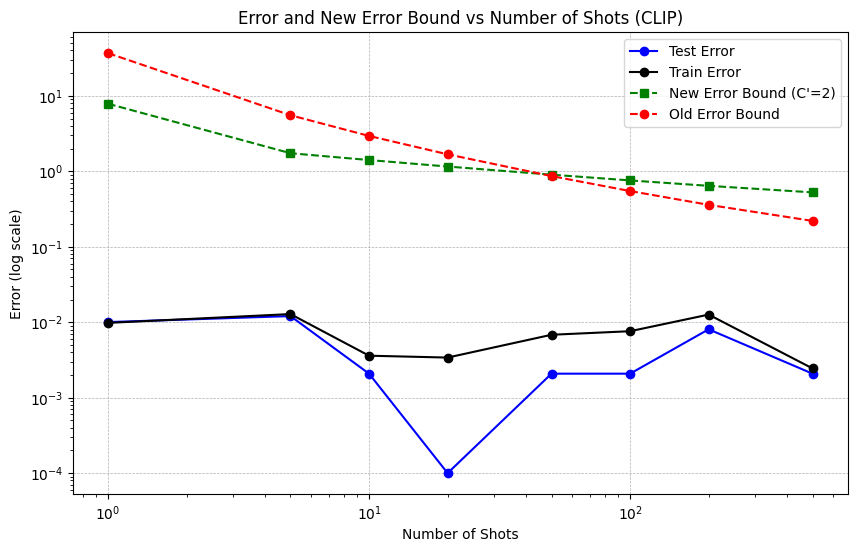

In [36]:
# Compute per-class stats and new bound, then plot
import torch
import numpy as np
from eval_utils.geometry import GeometricEvaluator

# Extract features
num_classes = config['dataset']['num_output_classes']
geometric_evaluator = GeometricEvaluator(num_classes=num_classes, device=device)
feature_extractor = FeatureExtractor(ssl_model, device=device)
train_features, train_labels = feature_extractor.extract_features(train_loader)

# Use first embedding head by default
embs = train_features[0] if isinstance(train_features, (list, tuple)) else train_features
lbls = train_labels[0] if isinstance(train_labels, (list, tuple)) else train_labels

if torch.is_tensor(embs):
    embs = embs.detach().cpu()
else:
    embs = torch.tensor(embs)

if torch.is_tensor(lbls):
    lbls = lbls.detach().cpu()
else:
    lbls = torch.tensor(lbls)

# Per-class partition
per_class_embeddings = {}
unique_classes = torch.unique(lbls).tolist()
for cl in unique_classes:
    mask = (lbls == cl)
    per_class_embeddings[int(cl)] = embs[mask]

# Means and covariances
per_class_means = {cl: e.mean(dim=0) for cl, e in per_class_embeddings.items()}
per_class_covariances = {}
for cl, e in per_class_embeddings.items():
    centered = e - per_class_means[cl]
    cov_matrix = (centered.T @ centered) / max(centered.shape[0] - 1, 1)
    per_class_covariances[cl] = cov_matrix

# Pairwise geometry
d_ij = {}
v_ij = {}
for i in unique_classes:
    for j in unique_classes:
        if i != j:
            mean_i = per_class_means[i]
            mean_j = per_class_means[j]
            cov_i = per_class_covariances[i]
            mean_diff = mean_j - mean_i
            d_ij[(i, j)] = torch.sqrt(torch.clamp(mean_diff @ mean_diff, min=0)).item()
            u = (mean_diff / max(d_ij[(i, j)], 1e-9))
            v_ij[(i, j)] = (u.T @ cov_i @ u).item()

# Choose C' classes and compute bound over m from CSV
C = 2
rng = np.random.default_rng(42)
chosen_classes = rng.choice(unique_classes, size=C, replace=False).tolist()
alpha_val = alpha(C)

m_shots_list = grouped_test.index.tolist() if grouped_test is not None else []
new_bounds = []
for m in m_shots_list:
    # B per class
    B_values = {}
    for cl in chosen_classes:
        cov = per_class_covariances[cl].numpy() if torch.is_tensor(per_class_covariances[cl]) else per_class_covariances[cl]
        B_values[cl] = B_i(cov, alpha_val, m)

    # Delta per pair
    delta_values = {}
    for i in chosen_classes:
        for j in chosen_classes:
            if i != j:
                vij = float(v_ij[(i, j)])
                vji = float(v_ij[(j, i)])
                dij = float(d_ij[(i, j)])
                e_d = eij_dir(vij, vji, m, alpha_val)
                e_q = eij_quad(B_values[i], B_values[j], dij)
                delta_values[(i, j)] = delta_ij(dij, e_d, e_q)

    # c_i and alpha caps
    d_float = {k: float(v) for k, v in d_ij.items() if k[0] in chosen_classes and k[1] in chosen_classes}
    c_values = {cl: c_i(B_values, d_float, cl, chosen_classes) for cl in chosen_classes}
    alpha_cap_values = {cl: alpha_i_cap(B_values, d_float, delta_values, cl, chosen_classes) for cl in chosen_classes}

    # alpha* per class
    alpha_star_values = {}
    for cl in chosen_classes:
        cov_np = per_class_covariances[cl].numpy() if torch.is_tensor(per_class_covariances[cl]) else per_class_covariances[cl]
        alpha_star_values[cl] = alpha_i_star(cov_np, c_values[cl], alpha_cap_values[cl])

    # Build inputs for bound
    v_float = {k: float(v) for k, v in v_ij.items() if k[0] in chosen_classes and k[1] in chosen_classes}
    cov_dict = {cl: (per_class_covariances[cl].numpy() if torch.is_tensor(per_class_covariances[cl]) else per_class_covariances[cl]) for cl in chosen_classes}

    bound = new_error_bound(cov_dict, v_float, delta_values, alpha_star_values, chosen_classes)
    new_bounds.append(bound)

# Plot
if m_shots_list:
    plt.figure(figsize=(10, 6))
    plt.yscale('log')
    plt.xscale('log')
    if grouped_test is not None:
        plt.plot(m_shots_list, grouped_test.values, marker='o', linestyle='-', color='b', label='Test Error')
    if grouped_train is not None:
        plt.plot(m_shots_list, grouped_train.values, marker='o', linestyle='-', color='k', label='Train Error')
    plt.plot(m_shots_list, new_bounds, marker='s', linestyle='--', color='g', label=f'New Error Bound (C\'={C})')
    plt.plot(m_shots, error_bounds, marker='o', linestyle='--', color='r', label='Old Error Bound')
    plt.title(f'Error and New Error Bound vs Number of Shots ({model.upper()})')
    plt.xlabel('Number of Shots')
    plt.ylabel('Error (log scale)')
    plt.grid(True, linestyle='--', linewidth=0.5)
    plt.legend()
    plt.show()
else:
    print("No m_shots found to plot new bound.")


In [ ]:
import numpy as np

# Numerical guards
EPS = 1e-12
FUDGE = 1e-2  # Helps prevent Delta=0 at small m; tune if needed

def alpha(c):
    return 2*c*(c-1) + c

def K_k(alpha):
    return np.floor(8*np.log(alpha/1e-4))

def b_k(m,k):
    return np.ceil(m/k)

def B_i(cov, alpha, m):
    # cov: numpy array
    return FUDGE * 8*np.sqrt(2) * np.sqrt(np.trace(cov)) * np.sqrt(np.log(alpha/1e-4)) / max(np.sqrt(m), EPS)

def eij_dir(v_ij, v_ji, m, alpha):
    v_ij = max(float(v_ij), 0.0)
    v_ji = max(float(v_ji), 0.0)
    return FUDGE * 8*np.sqrt(2) * (np.sqrt(v_ij) + np.sqrt(v_ji)) * np.sqrt(np.log(alpha/1e-4)) / max(np.sqrt(m), EPS)

def eij_quad(B_i_val, B_j_val, d_ij):
    return (max(B_i_val, B_j_val) ** 2) / max(float(d_ij), EPS)

def c_i(B, d, i, classes):
    result = 0.0
    for j in classes:
        if j != i:
            B_i_val = B[i]
            B_j_val = B[j]
            d_ij_val = d[(i, j)]
            result += np.sqrt(B_i_val**2 + B_j_val**2) / max(float(d_ij_val), EPS)
    return float(result)

def delta_ij(d_ij, eij_d, eij_q):
    return float(np.max([0.0, 0.5*float(d_ij) - float(eij_d) - float(eij_q)]))

def alpha_i_cap(B, d, delta, i, classes):
    min_val = np.inf
    for j in classes:
        if j != i:
            B_i_val = B[i]
            B_j_val = B[j]
            d_ij_val = d[(i, j)]
            delta_ij_val = delta[(i, j)]
            numerator = float(delta_ij_val) * float(d_ij_val)
            denominator = 2.0 * np.sqrt(B_i_val**2 + B_j_val**2)
            if denominator > 0 and numerator > 0:
                val = numerator / denominator
                min_val = min(min_val, val)
    return 0.0 if min_val == np.inf else float(min_val)

def alpha_i_star(cov_i, c_i_val, alpha_cap_i):
    trace_cov = float(np.trace(cov_i))
    c_safe = max(float(c_i_val), EPS)
    base = (2.0 * trace_cov / c_safe) ** (1.0/3.0)
    if alpha_cap_i > 0:
        val = min(base, float(alpha_cap_i))
    else:
        val = base
    return float(max(val, EPS))

def new_error_bound(cov, v, delta, alpha_star, classes):
    C_prime = len(classes)
    total_sum = 0.0
    for i in classes:
        sum_j = 0.0
        for j in classes:
            if j != i:
                vij = float(v[(i, j)])
                delt = float(delta[(i, j)])
                denom = max(vij + 0.25 * (delt ** 2), EPS)
                sum_j += min(max(vij / denom, 0.0), 1.0)
        tr_i = float(np.trace(cov[i]))
        a_i = max(float(alpha_star[i]), EPS)
        total_sum += sum_j + tr_i / (a_i*a_i)
    return total_sum / C_prime if C_prime > 0 else 0.0


In [24]:
# Debug one m to inspect terms contributing to inf
# Ensure EPS is defined here for safety, even if the previous cell wasn't run
try:
    EPS
except NameError:
    EPS = 1e-12

if len(m_shots_list) > 0:
    m_dbg = m_shots_list[0]
    print(f"\n[DEBUG] Inspecting terms for m={m_dbg} and classes {chosen_classes}")

    alpha_val_dbg = alpha(C)

    # B values
    B_dbg = {}
    for cl in chosen_classes:
        cov = per_class_covariances[cl]
        cov_np = cov.numpy() if torch.is_tensor(cov) else cov
        B_dbg[cl] = B_i(cov_np, alpha_val_dbg, m_dbg)
    print("B values:", {k: float(v) for k, v in B_dbg.items()})

    # Pairwise terms
    for i in chosen_classes:
        for j in chosen_classes:
            if i == j:
                continue
            v_ij_val = float(v_ij[(i, j)])
            v_ji_val = float(v_ij[(j, i)])
            d_ij_val = float(d_ij[(i, j)])
            eij_d = eij_dir(v_ij_val, v_ji_val, m_dbg, alpha_val_dbg)
            eij_q = eij_quad(B_dbg[i], B_dbg[j], d_ij_val)
            delta_val = delta_ij(d_ij_val, eij_d, eij_q)
            denom = max(v_ij_val + 0.25*(delta_val**2), EPS)
            print(f"pair ({i},{j}): v_ij={v_ij_val:.6e}, d_ij={d_ij_val:.6e}, e_dir={eij_d:.6e}, e_quad={eij_q:.6e}, Delta={delta_val:.6e}, denom={denom:.6e}")

    # c_i and alpha caps
    d_ij_float = {k: float(v) for k, v in d_ij.items() if k[0] in chosen_classes and k[1] in chosen_classes}
    c_vals_dbg = {cl: c_i(B_dbg, d_ij_float, cl, chosen_classes) for cl in chosen_classes}
    delta_vals_dbg = {}
    for i in chosen_classes:
        for j in chosen_classes:
            if i != j:
                v_ij_val = float(v_ij[(i, j)])
                v_ji_val = float(v_ij[(j, i)])
                d_ij_val = float(d_ij[(i, j)])
                eij_d = eij_dir(v_ij_val, v_ji_val, m_dbg, alpha_val_dbg)
                eij_q = eij_quad(B_dbg[i], B_dbg[j], d_ij_val)
                delta_vals_dbg[(i, j)] = delta_ij(d_ij_val, eij_d, eij_q)
    alpha_cap_dbg = {cl: alpha_i_cap(B_dbg, d_ij_float, delta_vals_dbg, cl, chosen_classes) for cl in chosen_classes}
    alpha_star_dbg = {}
    for cl in chosen_classes:
        cov = per_class_covariances[cl]
        cov_np = cov.numpy() if torch.is_tensor(cov) else cov
        alpha_star_dbg[cl] = alpha_i_star(cov_np, c_vals_dbg[cl], alpha_cap_dbg[cl])

    print("c_i:", {k: float(v) for k, v in c_vals_dbg.items()})
    print("alpha_cap:", {k: float(v) for k, v in alpha_cap_dbg.items()})
    print("alpha_star:", {k: float(v) for k, v in alpha_star_dbg.items()})

    # Second term check
    for cl in chosen_classes:
        cov = per_class_covariances[cl]
        cov_np = cov.numpy() if torch.is_tensor(cov) else cov
        tr = float(np.trace(cov_np))
        a = max(float(alpha_star_dbg[cl]), EPS)
        print(f"class {cl}: trace={tr:.6e}, alpha*={a:.6e}, trace/alpha^2={tr/(a*a):.6e}")


[DEBUG] Inspecting terms for m=1 and classes [36, 61]
B values: {36: 7.605276344497126, 61: 6.940299069941306}
pair (36,61): v_ij=7.311883e+00, d_ij=1.701774e+01, e_dir=2.246479e+00, e_quad=3.398819e+00, Delta=2.863573e+00, denom=9.361896e+00
pair (61,36): v_ij=1.077327e+01, d_ij=1.701774e+01, e_dir=2.246479e+00, e_quad=3.398819e+00, Delta=2.863573e+00, denom=1.282329e+01
c_i: {36: 0.6050166676270422, 61: 0.6050166676270422}
alpha_cap: {36: 2.3665237761950615, 61: 2.3665237761950615}
alpha_star: {36: 2.3665237761950615, 61: 2.3665237761950615}
class 36: trace=4.107187e+02, alpha*=2.366524e+00, trace/alpha^2=7.333693e+01
class 61: trace=3.420352e+02, alpha*=2.366524e+00, trace/alpha^2=6.107298e+01
